In [1]:
# For google colab
# Upload the folder containing this file to google drive if using colab.
import sys, os

# Checking if the notebook is opened in google colab
#If YES, mount the google drive and change the directory
if 'google.colab' in sys.modules:

    # mount google drive
    from google.colab import drive
    drive.mount('/content/drive')

    # change path to the folder
    path = '/content/drive/My Drive/CS5242Project'
    print(path)
    #os.chdir changes the current working directory
    os.chdir(path)
    !pwd


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from transformers import BertTokenizerFast

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader           

from sklearn.utils.class_weight import compute_class_weight

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial
import logging
from logging import StreamHandler

import time

from utils import set_device, load_dataset
from transformer_utils import TransformerNewsDataset, cosine_with_warmup_lr_lambda
from models.bert import Bert

torch.manual_seed(42)
np.random.seed(42)

handler = StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

logger = logging.getLogger()
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(handler)

device = set_device()
print('Using device:', device)

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

datasets = {
    'combined': [
        'data/combined_transformers_train_preprocessed.csv', 
        'data/combined_transformers_test_preprocessed.csv'
        ],
    'base': [
        'data/transformers_train_preprocessed.csv', 
        'data/transformers_test_preprocessed.csv'
        ],  
}

max_length = 128

for k, v in datasets.items():
    for i, t in enumerate(v):
        X, y , classes = load_dataset(t)
        datasets[k][i] = (X, y)
        datasets[k][i] = TransformerNewsDataset(datasets[k][i][0], datasets[k][i][1], tokenizer, max_len=max_length)

train, test = datasets['base']


Using device: cuda


In [3]:
# Global settings

# tokenizer settings
max_length = 128

# validation dataset settings
USE_TEST_AS_VALID = False 

# learning rate and scheduler settings
lr = 1e-3
num_epochs = 30
batch_size = 64
num_cycles = 0.5
warmup_steps_scaler = 0.1
last_epoch = -1

# training settings
batch_size = 64
max_epochs = 30
loss_func = nn.CrossEntropyLoss
optimizer = torch.optim.AdamW

In [4]:
# Additional calculated variables

if USE_TEST_AS_VALID:
    train_split = predefined_split(test)
else:
    train_split = ValidSplit(0.2, stratified=True)

    
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
total_steps = len(train_loader) * num_epochs
num_warmup_steps = int(warmup_steps_scaler * total_steps)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train.labels), y=train.labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
unique_labels = np.unique(train.labels)

In [5]:
net = partial(NeuralNetClassifier,
    module=partial(Bert, num_labels=len(unique_labels)),
    criterion=partial(loss_func, weight=class_weights_tensor),
    optimizer=optimizer,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(
            policy=LambdaLR,
            lr_lambda=partial(
                cosine_with_warmup_lr_lambda, 
                num_warmup_steps=num_warmup_steps, 
                num_cyles=num_cycles
            ),
            last_epoch=last_epoch
                   ),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

net = net(train_split=train_split)

In [6]:
print('Training Base datset net')
net.fit(train, torch.tensor(train.labels))
print('=' * 10)

Training Base datset net
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.0937      0.0381        1.7041       0.0771      0.0261        1.7296  0.0000  18.9285
      2       0.1953      0.1594        1.6102       0.3629      0.3897        1.5732  0.0000  18.8932
      3       0.3376      0.3550        1.5089       0.3286      0.3456        1.4763  0.0000  18.9393
      4       0.4599      0.4813        1.3280       0.4600      0.4854        1.3810  0.0000  18.9939
      5       0.5644      0.5812        1.0997       0.5914      0.5956        1.2545  0.0000  19.0081
      6       0.6795      0.6879        0.7810       0.5257      0.5380        1.5733  0.0001  19.0678
      7       0.7425      0.7486        0.5588       0.5886      0.5810        1.6346  0.0001  19.1264
      8       0.7854      0.7908        0.4788  

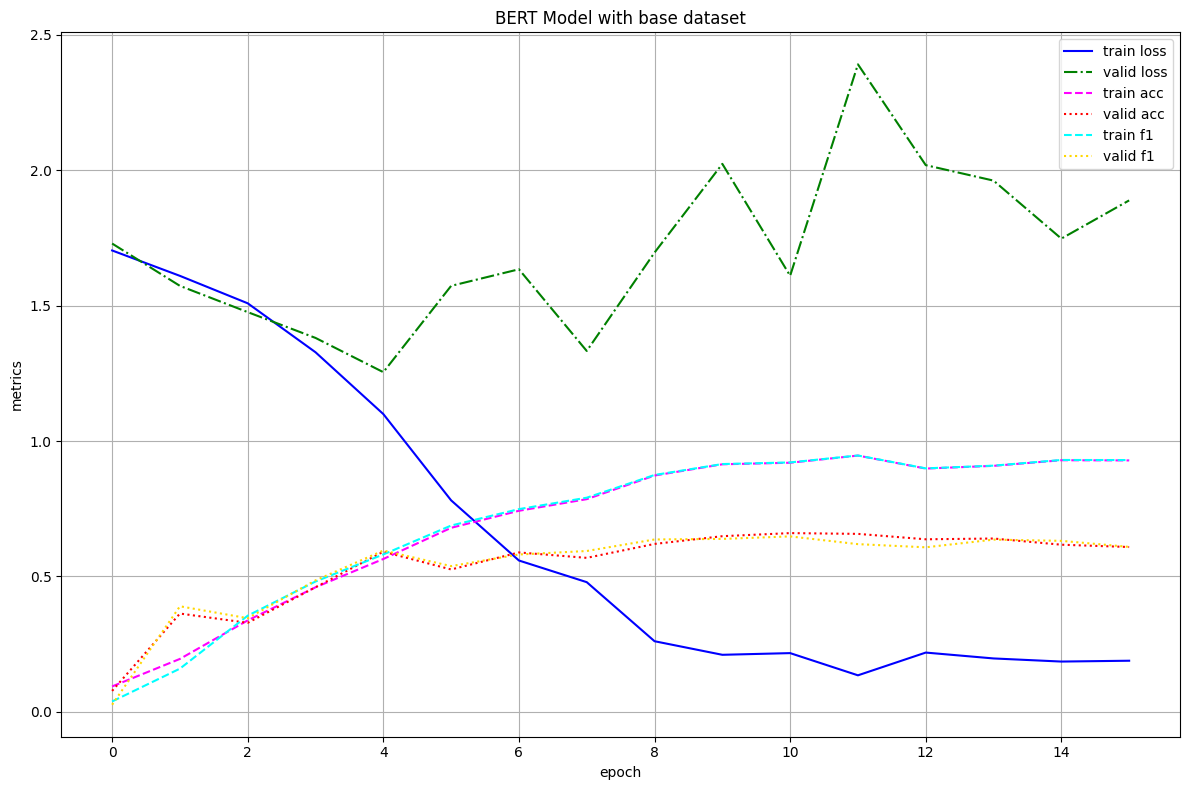

In [7]:
from utils import plot_result_curves

plot_result_curves(net, 'BERT Model with base dataset');

# Evaluation

We ran BERT against two datasets, the first version is the base dataset and the second version is our base dataset combined with scraped data to reduce our class imbalance.

While the BERT model performed well on both datasets, the combined dataset clearly performed better. The base dataset showed signs of overfitting after epoch 4, with loss diverging between our validation set and training set, though accuracy and f1 scores stayed relatively stable.

The combined dataset showed better performance, with a lower loss value on the validation set and a higher accuracy and f1 score. It also reached its optimal point faster than the base version, maximising the f1 score at about epoch 8 versus epoch 12 for the base dataset version.

In [8]:
y_pred = net.predict(test.embed_all())
y_prob = net.predict_proba(test.embed_all())

In [9]:
from utils import print_evaluation_report

print_evaluation_report(y_pred, test, classes, 'BERT Base Dataset')

BERT Base Dataset Accuracy: 60.41%
BERT Base Dataset Weighted F1-score: 0.6104

Classification Report:
               precision    recall  f1-score   support

      center     0.2909    0.3902    0.3333        41
   lean left     0.4667    0.4590    0.4628        61
  lean right     0.3396    0.4865    0.4000        37
        left     0.7870    0.7658    0.7763       222
       right     0.6038    0.4211    0.4961        76

    accuracy                         0.6041       437
   macro avg     0.4976    0.5045    0.4937       437
weighted avg     0.6260    0.6041    0.6104       437



# Classification report summary

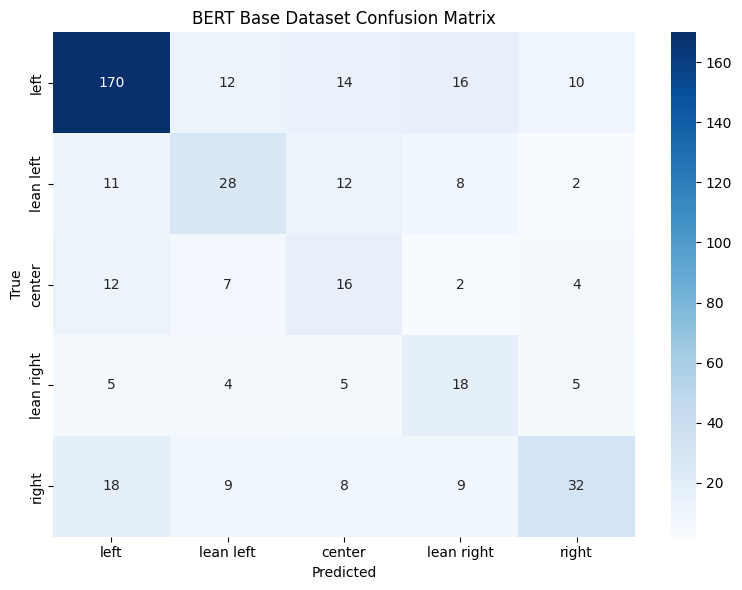

In [10]:
# Define correct label order
from utils import plot_confusion_matrix

plot_confusion_matrix(y_pred, test, classes, 'BERT Base Dataset');

In [11]:
from utils import show_one_vs_rest_confusion_matrices

print('Confusion matrics for BERT Base Dataset')
show_one_vs_rest_confusion_matrices(net, y_pred, test, classes)

Confusion matrics for BERT Base Dataset

One-vs-Rest Confusion Matrix for class 'center':
[[357  39]
 [ 25  16]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[344  32]
 [ 33  28]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[365  35]
 [ 19  18]]

One-vs-Rest Confusion Matrix for class 'left':
[[169  46]
 [ 52 170]]

One-vs-Rest Confusion Matrix for class 'right':
[[340  21]
 [ 44  32]]


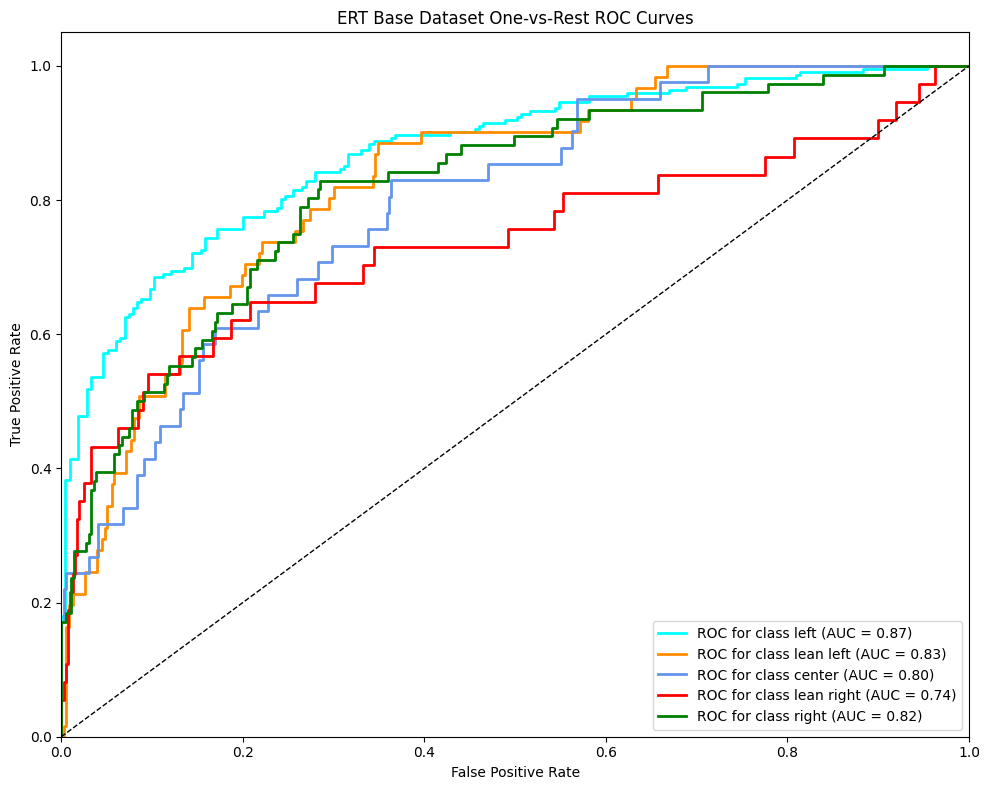

In [12]:
from utils import plot_roc

plot_roc(y_prob, net, test, classes, 'ERT Base Dataset');